# 15 — Fingerprint da Escavadeira por Lift Preditivo (Sprint 11)

**Motivação:** Sprint 2 mostrou o modelo cego à escavadeira (Recall=0,14); Sprint 5 mostrou que um modelo dedicado também falha. Trabalho futuro #1 hipotetizou que o problema é **feature engineering** — o fingerprint global seleciona alarmes por **frequência**, mas a escavadeira gera 91% de todos os eventos, então esses alarmes são ruído rotineiro dela própria.

**Método:** trocamos o critério de FREQUÊNCIA por **LIFT PREDITIVO** — quanto a presença de cada alarme num evento eleva a probabilidade de Don't Go nos próximos 60min — calculado separadamente para escavadeira e caminhões.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
d = json.loads((ROOT / 'outputs' / 'gold' / 'escavadeira_fingerprint.json').read_text())
fig_dir = ROOT / 'outputs' / 'figures'
print(f"Base rate escavadeira: {d['base_rate_escavadeira']:.3%} | caminhão: {d['base_rate_caminhao']:.3%}")

Base rate escavadeira: 0.376% | caminhão: 12.363%


## 1. Fingerprint da Escavadeira por Lift — Top 10

Coluna `no_top30_global` = o alarme já está no fingerprint atual do modelo (seleção por frequência)?

In [2]:
esc = pd.DataFrame(d['escavadeira_top_alarms_by_lift']).head(10)
esc['no_modelo_atual'] = esc['no_top30_global'].map({True:'sim', False:'NÃO'})
esc[['Id_Alarme','Alarme','suporte','taxa_pre_dg','lift','no_modelo_atual']]

,Id_Alarme,Alarme,suporte,taxa_pre_dg,lift,no_modelo_atual
0,1074008237,Channel Forced (L-1850),8094,0.166914,44.399421,NÃO
1,16830311,MC - TEMPERATURA DO PTO >90°C,1791,0.107761,28.664666,NÃO
2,1074008199,Hydraulic Reservoir Air Pressure High (L-1850),2534,0.015391,4.093956,NÃO
3,1241586690,Fan Drive State - Excessive Engine Air Tempera...,652,0.015337,4.079788,NÃO
4,1074008236,Bucket Critical Overload: Dump Some Load And R...,1864,0.013948,3.710331,NÃO
5,1074008005,Bucket Critical Overload (L-1850),1904,0.013655,3.632382,NÃO
6,1074008006,Bucket Overload (L-1850),13797,0.012974,3.451068,NÃO
7,1074008250,Red Alarm(s) Active (L-1850),931,0.011815,3.142883,NÃO
8,16834563,MC - ALTA TEMP. ARREF. DO MOTOR >90°C,3748,0.009872,2.625955,NÃO
9,1074008172,Front Driver Lubrication Flow Switch Fault (L-...,338,0.008876,2.360966,NÃO


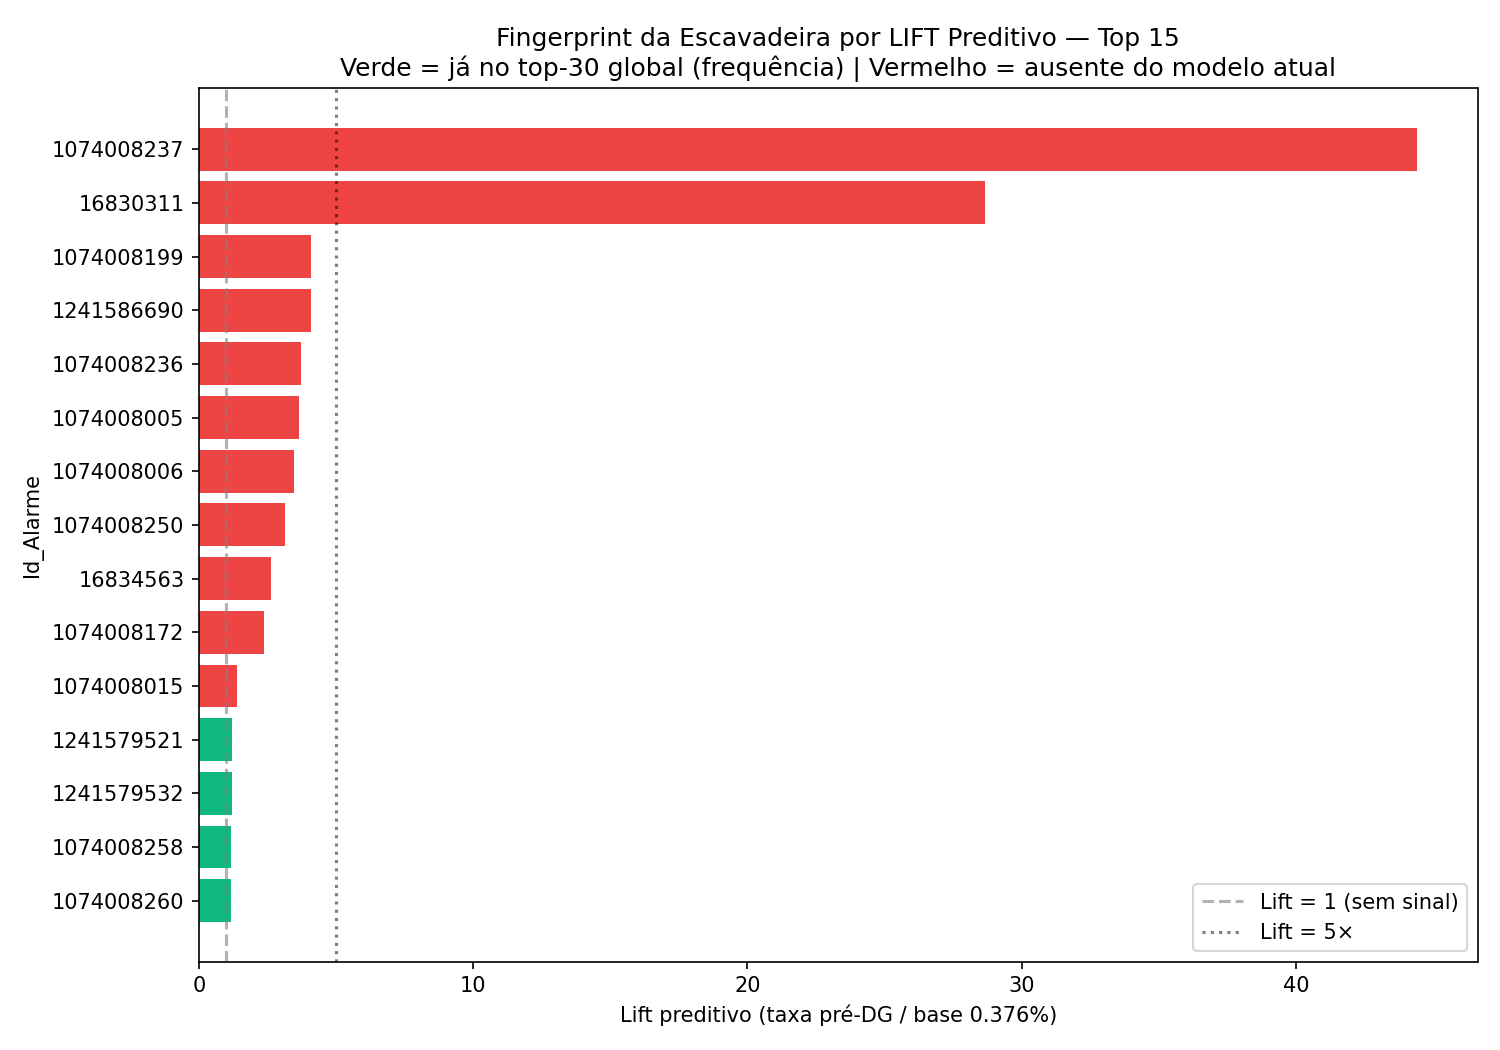

In [3]:
display(Image(filename=str(fig_dir / 'escavadeira_fingerprint_lift.png')))

## 2. Escavadeira vs. Caminhões — Força do Sinal e Cobertura

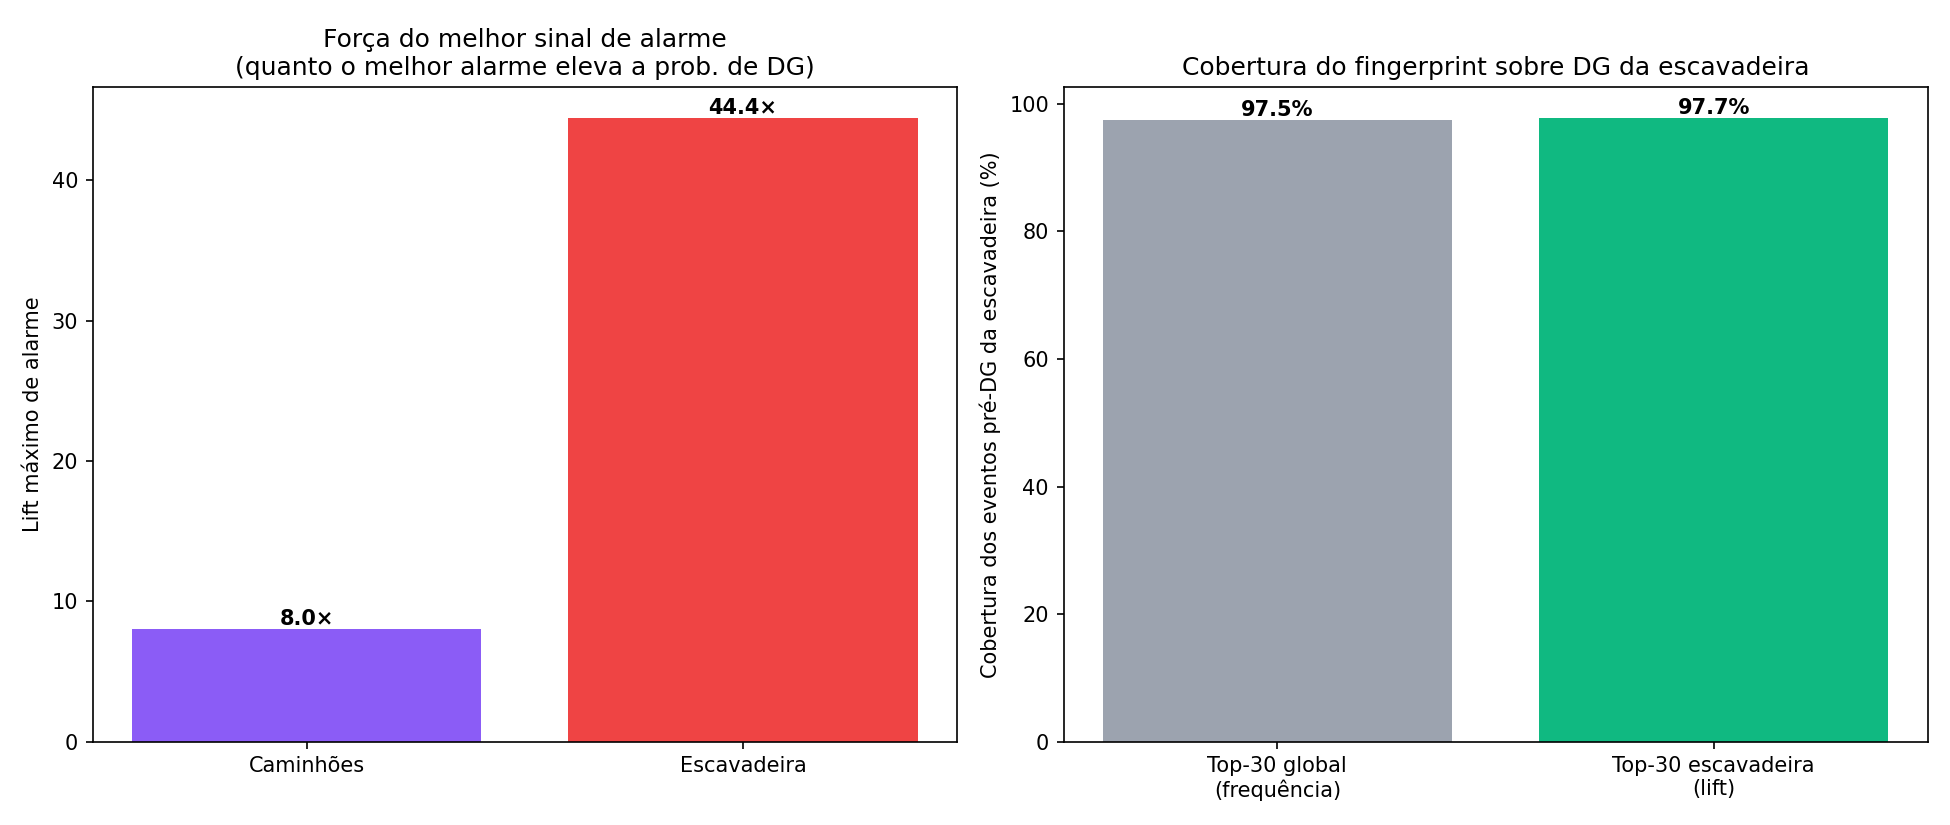

In [4]:
display(Image(filename=str(fig_dir / 'escavadeira_vs_caminhao_fingerprint.png')))

In [5]:
diag = d['diagnostics']; cov = d['coverage_pre_dg_escavadeira']
print(f"Lift máximo escavadeira: {diag['max_lift_escavadeira']:.1f}x (taxa {diag['max_rate_escavadeira']:.1%})")
print(f"Lift máximo caminhões:   {diag['max_lift_caminhao']:.1f}x")
print(f"Alarmes escavadeira com lift >= 5x: {diag['n_alarms_lift_ge_5_escavadeira']}")
print(f"Cobertura pré-DG escavadeira — top30 global (freq): {cov['global_top30_freq']:.1%}")
print(f"Cobertura pré-DG escavadeira — top30 escavadeira (lift): {cov['escavadeira_top30_lift']:.1%}")
n_fora = sum(1 for r in d['escavadeira_top_alarms_by_lift'][:8] if not r['no_top30_global'])
print(f"Top-8 alarmes de lift AUSENTES do modelo atual: {n_fora}/8")

Lift máximo escavadeira: 44.4x (taxa 16.7%)
Lift máximo caminhões:   8.0x
Alarmes escavadeira com lift >= 5x: 2
Cobertura pré-DG escavadeira — top30 global (freq): 97.5%
Cobertura pré-DG escavadeira — top30 escavadeira (lift): 97.7%
Top-8 alarmes de lift AUSENTES do modelo atual: 8/8


## 3. Diagnóstico e Recomendação

**Achado central — os 8 alarmes de maior lift da escavadeira estão TODOS ausentes do fingerprint atual.** Os dois mais fortes:
- **`Channel Forced` (lift 44×, taxa pré-DG 16,7%)** — falha de canal de controle.
- **`MC - Temperatura do PTO >90°C` (lift 28,7×, 10,8%)** — superaquecimento da tomada de força.

Ambos são mecanicamente interpretáveis e raros (suporte de poucos milhares de eventos). É justamente por serem raros que o critério de **frequência** os descarta — sepultando o sinal mais forte.

**Diagnóstico refinado (corrige leitura anterior):** NÃO é verdade que a escavadeira não tenha sinal — ela tem lift até **44×**, contra no máximo **8×** nos caminhões. O que ocorre:
1. Os sinais fortes são **raros** → poucos eventos pré-DG os contêm.
2. O critério de seleção por **frequência** os exclui do fingerprint.
3. A cobertura é quase idêntica entre os critérios (~97,5%) porque a **maioria** dos eventos pré-DG da escavadeira só traz alarmes rotineiros — mas o subconjunto que dispara `Channel Forced`/`PTO>90°C` é **altamente recuperável e hoje 100% perdido**.

**Isto refina o Sprint 5:** o modelo dedicado falhou não por ausência de sinal, mas por reutilizar o feature set baseado em frequência. **Correção concreta:** adicionar os top-8 alarmes de alto lift da escavadeira como features binárias dedicadas e retreinar, medindo o ganho de recall na LeTourneau.